# Circuit mapping and car position

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [65]:
df_map = pd.read_parquet("../data/artifacts/circuit_map_Y2026R02S1_Y2026R02S2_Y2026R02S3_Y2026R02S4.parquet")
df_map

,encoding,coordinate_x,coordinate_y,coordinate_z,derivative_x,derivative_y,derivative_z,total_distance_m,distance_m
0,0.00000,375.346504,-1481.336095,141.756571,-77519.977743,-17922.740280,90.690621,5428.506095,0.000000
1,0.00001,374.571303,-1481.515326,141.757477,-77520.230854,-17923.428666,90.609154,5428.506095,0.079565
2,0.00002,373.796100,-1481.694563,141.758383,-77520.435876,-17924.095896,90.526215,5428.506095,0.159131
3,0.00003,373.020894,-1481.873808,141.759288,-77520.592800,-17924.741963,90.441807,5428.506095,0.238696
4,0.00004,372.245688,-1482.053058,141.760192,-77520.701614,-17925.366862,90.355932,5428.506095,0.318262
...,...,...,...,...,...,...,...,...,...
99995,0.99995,379.222458,-1480.440050,141.752026,-77517.991252,-17918.981173,91.075746,5428.506095,5428.108277
99996,0.99996,378.447276,-1480.619243,141.752937,-77518.484636,-17919.775266,91.001693,5428.506095,5428.187840
99997,0.99997,377.672089,-1480.798445,141.753846,-77518.929989,-17920.548229,90.926151,5428.506095,5428.267403
99998,0.99998,376.896897,-1480.977654,141.754755,-77519.327299,-17921.300056,90.849122,5428.506095,5428.346966


In [66]:
vec_position = df_map[['coordinate_x', 'coordinate_y']].values
vec_derivative = df_map[['derivative_x', 'derivative_y', 'derivative_z']].values

In [67]:
norm = np.sqrt(np.sum(vec_derivative**2, axis=1))

In [68]:
pd.Series(norm).describe()

count    100000.000000
mean      54289.025996
std       21430.836334
min       15505.201712
25%       37341.205997
50%       57704.459839
75%       69509.054552
max      110780.392859
dtype: float64

<Axes: ylabel='Frequency'>

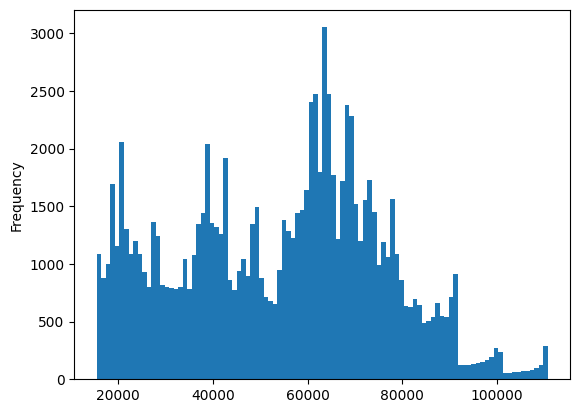

In [69]:
pd.Series(norm).plot.hist(bins=100)

<Axes: ylabel='Frequency'>

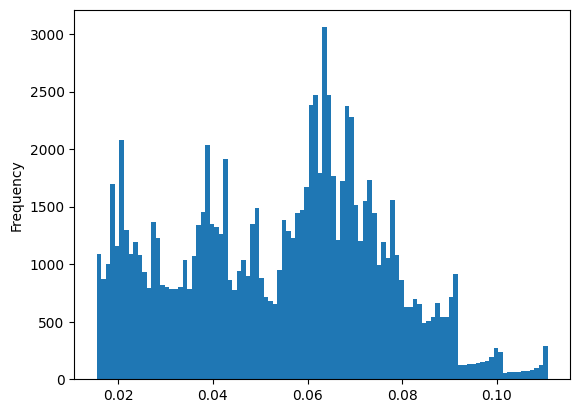

In [70]:
pd.Series(np.diff(df_map['distance_m'].values)).plot.hist(bins=100)

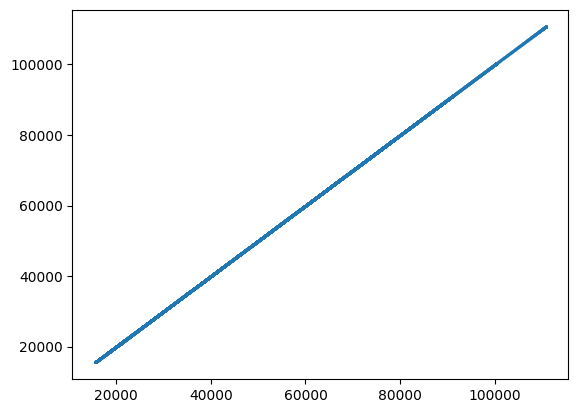

In [71]:
xx = pd.Series(norm)
yy = pd.Series(np.diff(df_map['distance_m'].values)) * 1e6
fig, ax = plt.subplots()
ax.scatter(xx[1:], yy, s=1, alpha=0.2)

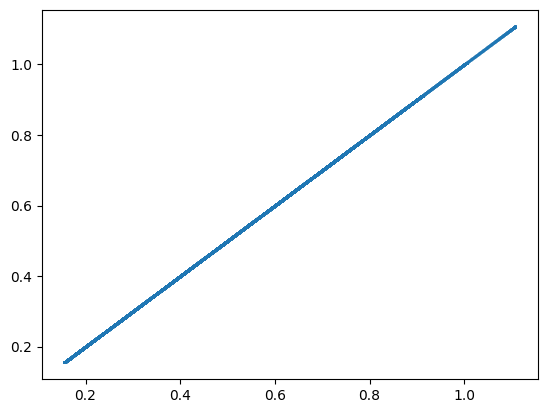

In [72]:
xx = np.sqrt(
    (df_map['coordinate_x'] - df_map['coordinate_x'].shift(1)) ** 2
    + (df_map['coordinate_y'] - df_map['coordinate_y'].shift(1)) ** 2
)
yy = pd.Series(np.diff(df_map['distance_m'].values)) * 1e1
fig, ax = plt.subplots()
ax.scatter(xx[1:], yy[:], s=1, alpha=0.2)



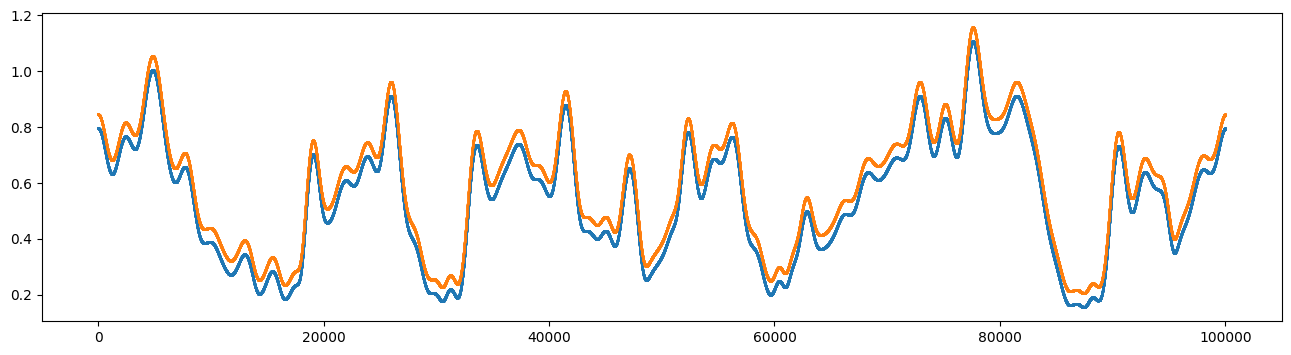

In [73]:
fig, ax = plt.subplots(figsize=(16, 4))
ax.scatter(range(len(xx)), xx, s=1, alpha=0.2)
ax.scatter(range(len(yy)), yy+0.05, s=1, alpha=0.2)
